# Load the AIS data and visualize your first ship trajectory

## Import relevant libraries

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv('../data/AIS_data.csv')

In [3]:
# Filter records for the specific ship (IMO = 9595527)
df_ship = df[df['IMO'] == 9595527].copy()
df_ship

,IMO,Date/Time,Lat,Lng,Heading,SOG,COG,draught,Navigation status
0,9595527,2021-04-24 21:32:00,34.247222,129.783611,230.0,21.4,230.3,12.0,Under Way
1,9595527,2021-04-24 21:35:00,34.235556,129.767500,230.0,21.2,228.6,12.0,Under Way
2,9595527,2021-04-24 21:38:00,34.224167,129.751111,230.0,21.1,229.3,12.0,Under Way
3,9595527,2021-04-24 21:41:00,34.212778,129.735000,230.0,21.1,229.4,12.0,Under Way
4,9595527,2021-04-24 21:44:00,34.201667,129.719444,230.0,21.1,229.7,12.0,Under Way
...,...,...,...,...,...,...,...,...,...
474,9595527,2021-10-05 00:15:00,34.257500,129.721944,47.0,23.1,46.4,14.1,Under Way
475,9595527,2021-10-05 00:18:00,34.268611,129.737222,53.0,23.1,52.6,14.1,Under Way
476,9595527,2021-10-05 00:20:00,34.279167,129.754167,52.0,22.9,52.0,14.1,Under Way
477,9595527,2021-10-05 00:21:00,34.279444,129.754444,52.0,22.9,52.0,14.1,Under Way


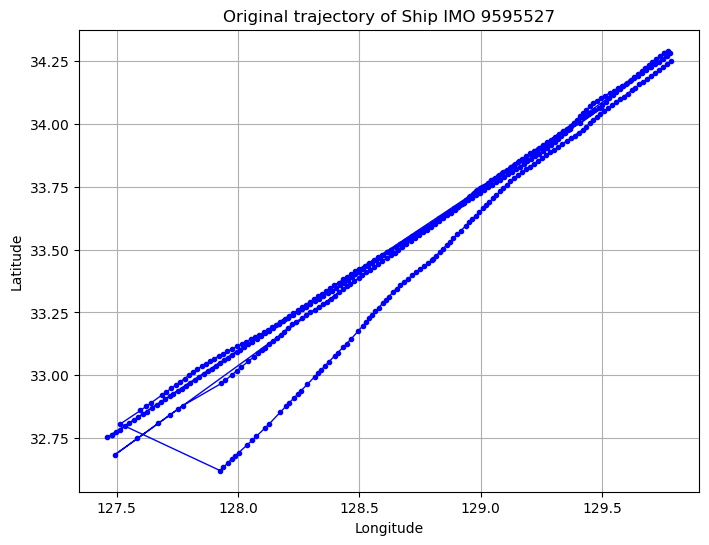

In [4]:
# Plot the ship trajectory (Lat vs Lng)
plt.figure(figsize=(8, 6))
plt.plot(df_ship['Lng'], df_ship['Lat'], marker='o', markersize=3, linewidth=1, color='blue')
# Add title and labels
plt.title('Original trajectory of Ship IMO 9595527', fontsize=12)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.grid(True)
plt.show()

## Splitting AIS Data into Multiple Trajectories

In real-world AIS datasets, ships may temporarily stop reporting their
positions due to signal loss, equipment shutdown, or port operations.
When this happens, the time gap between two consecutive AIS messages
can become very large.

To analyze vessel movement correctly, we usually treat each continuous
sequence of AIS messages as one trajectory. When the time gap is larger
than a user-defined threshold (for example, 24 hours), we start a new
trajectory segment.

The function below automatically:

1. Sorts AIS records in chronological order  
2. Converts timestamp strings into proper datetime objects  
3. Computes the time gap (in hours) between consecutive AIS points  
4. Assigns a new `traj_id` whenever the gap exceeds the threshold  
5. Returns the AIS dataframe with a new `traj_id` column  


In [5]:
def split_traj_by_gap(df_ship, time_col='Date/Time', gap_hours=24):
    """
    Split AIS records into separate trajectories whenever the observation gap
    between two consecutive AIS points exceeds a specified number of hours.
    A new trajectory ID (traj_id) is assigned to each continuous segment.
    
    Parameters
    ----------
    df_ship : pandas.DataFrame
        AIS dataframe containing records of a single ship.
    
    time_col : str
        Name of the timestamp column in df_ship.
    
    gap_hours : int or float
        Threshold (in hours) above which a new trajectory segment will be created.
    
    Returns
    -------
    pandas.DataFrame
        The original dataframe with an additional 'traj_id' column indicating
        the trajectory segment each AIS point belongs to.
    """

    # Ensure the dataframe is sorted in chronological order
    df_ship = df_ship.sort_values(time_col).copy()

    # Convert the timestamp column into pandas datetime format
    df_ship[time_col] = pd.to_datetime(df_ship[time_col])

    # Compute time difference (in hours) between consecutive AIS points
    df_ship["time_diff"] = df_ship[time_col].diff().dt.total_seconds() / 3600.0

    # Start a new trajectory whenever the gap exceeds the threshold
    # cumsum() increases by 1 each time the condition is True
    df_ship["traj_id"] = (df_ship["time_diff"] > gap_hours).cumsum() + 1

    # Remove helper column
    df_ship.drop(columns=["time_diff"], inplace=True)

    return df_ship
df_ship_split = split_traj_by_gap(df_ship, time_col='Date/Time', gap_hours=24)
df_ship_split

,IMO,Date/Time,Lat,Lng,Heading,SOG,COG,draught,Navigation status,traj_id
0,9595527,2021-04-24 21:32:00,34.247222,129.783611,230.0,21.4,230.3,12.0,Under Way,1
1,9595527,2021-04-24 21:35:00,34.235556,129.767500,230.0,21.2,228.6,12.0,Under Way,1
2,9595527,2021-04-24 21:38:00,34.224167,129.751111,230.0,21.1,229.3,12.0,Under Way,1
3,9595527,2021-04-24 21:41:00,34.212778,129.735000,230.0,21.1,229.4,12.0,Under Way,1
4,9595527,2021-04-24 21:44:00,34.201667,129.719444,230.0,21.1,229.7,12.0,Under Way,1
...,...,...,...,...,...,...,...,...,...,...
474,9595527,2021-10-05 00:15:00,34.257500,129.721944,47.0,23.1,46.4,14.1,Under Way,4
475,9595527,2021-10-05 00:18:00,34.268611,129.737222,53.0,23.1,52.6,14.1,Under Way,4
476,9595527,2021-10-05 00:20:00,34.279167,129.754167,52.0,22.9,52.0,14.1,Under Way,4
477,9595527,2021-10-05 00:21:00,34.279444,129.754444,52.0,22.9,52.0,14.1,Under Way,4


### 📌 Plotting a Ship Trajectory (traj_id = 1)

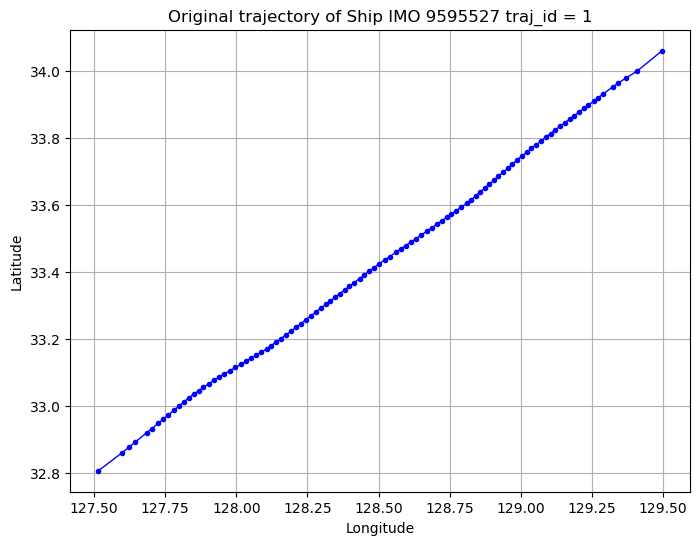

In [6]:
df_traj_1 = df_ship_split[df_ship_split['traj_id']==2]

# Plot the ship trajectory (Lat vs Lng)
plt.figure(figsize=(8, 6))
plt.plot(df_traj_1['Lng'], df_traj_1['Lat'], marker='o', markersize=3, linewidth=1, color='blue')

# Add title and labels
plt.title('Original trajectory of Ship IMO 9595527 traj_id = 1', fontsize=12)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.grid(True)
plt.show()

### 📌 Plotting a Ship Trajectory (traj_id = 2)

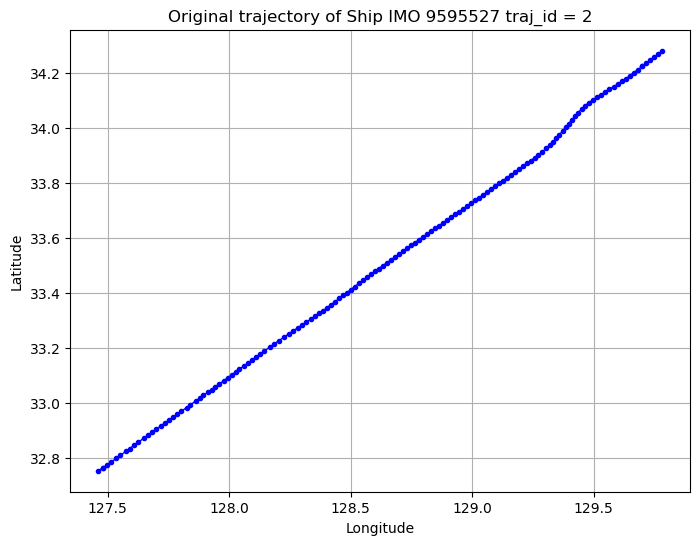

In [7]:
df_traj_2 = df_ship_split[df_ship_split['traj_id']==3]

# Plot the ship trajectory (Lat vs Lng)
plt.figure(figsize=(8, 6))
plt.plot(df_traj_2['Lng'], df_traj_2['Lat'], marker='o', markersize=3, linewidth=1, color='blue')

# Add title and labels
plt.title('Original trajectory of Ship IMO 9595527 traj_id = 2', fontsize=12)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.grid(True)
plt.show()

## Trajectory Compression Using the Douglas–Peucker Algorithm

### Overview
This code implements a classical **Douglas–Peucker (DP) trajectory compression algorithm** for AIS vessel trajectories.  
The objective is to reduce the number of trajectory points while preserving the essential geometric shape of the vessel path, thereby improving computational efficiency for subsequent analysis such as pattern recognition, clustering, or prediction.

### Core Idea
The Douglas–Peucker algorithm follows a **divide-and-conquer strategy**. It recursively identifies points that contribute most to the overall trajectory shape by measuring their perpendicular distance to a baseline connecting the start and end points of a trajectory segment. Points whose deviation exceeds a predefined threshold are retained as characteristic points, while redundant intermediate points are discarded.

### Key Components

#### Perpendicular Distance Calculation
The function `perpendicular_distance` computes the perpendicular distance from a set of intermediate points to a line segment defined by two endpoints.  
This distance is derived from the geometric relationship between a point and a line using the cross-product formulation, ensuring numerical stability and vectorized efficiency.

#### Recursive Trajectory Simplification
The function `douglas_peucker_compression` applies the Douglas–Peucker algorithm to an AIS trajectory stored in a DataFrame:
- The trajectory is first converted into a NumPy array for efficient numerical computation.
- A recursive function iteratively splits the trajectory at the point with the maximum perpendicular deviation.
- If the maximum deviation exceeds the threshold `epsilon`, the trajectory is subdivided and processed recursively.
- If the deviation is within the threshold, only the segment endpoints are retained.

### Inputs and Outputs
- **Input**:
  - A pandas DataFrame containing AIS trajectory data with latitude (`Lat`) and longitude (`Lng`) fields.
  - A distance threshold `epsilon` controlling the compression level.
- **Output**:
  - A compressed pandas DataFrame containing only the critical trajectory points, with original metadata (e.g., time, speed, course) preserved and temporal order maintained.

### Practical Notes
- When coordinates are expressed in geographic degrees (WGS-84), the threshold `epsilon` is also in degrees.
- For meter-level accuracy, trajectory coordinates should be projected to a planar coordinate system (e.g., UTM) prior to applying the algorithm.

This implementation provides a robust and interpretable preprocessing step for AIS data analysis, balancing data reduction and trajectory fidelity.


In [8]:
def perpendicular_distance(points, start_point, end_point):
    """
    Calculates the perpendicular distance of a set of points to the line segment 
    defined by a start_point and an end_point.
    
    Mathematical Formulation:
    The perpendicular distance d from point P(x0, y0) to the line defined by 
    points A(x1, y1) and B(x2, y2) is given by the magnitude of the cross product 
    divided by the base length:
    d = |(y2-y1)x0 - (x2-x1)y0 + x2y1 - y2x1| / sqrt((y2-y1)^2 + (x2-x1)^2)
    
    Parameters:
    - points: np.array, shape (N, 2), array of intermediate points (Lat, Lng).
    - start_point: np.array, shape (2,), the starting point of the segment.
    - end_point: np.array, shape (2,), the ending point of the segment.
    
    Returns:
    - distances: np.array, shape (N,), the distance of each point to the line.
    """
    # If start and end points are identical, distance is the Euclidean distance
    if np.array_equal(start_point, end_point):
        return np.linalg.norm(points - start_point, axis=1)

    # Vectorized Calculation
    # Extract coordinates. Note: Typically Lng is x, Lat is y.
    # points[:, 1] is Longitude (x0), points[:, 0] is Latitude (y0)
    x0, y0 = points[:, 1], points[:, 0]
    x1, y1 = start_point[1], start_point[0]
    x2, y2 = end_point[1], end_point[0]

    # Numerator: Absolute value of the Cross Product (Area of the parallelogram)
    numerator = np.abs((y2 - y1) * x0 - (x2 - x1) * y0 + x2 * y1 - y2 * x1)
    
    # Denominator: Length of the baseline (segment connecting start and end)
    denominator = np.sqrt((y2 - y1)**2 + (x2 - x1)**2)
    
    return numerator / denominator

def douglas_peucker_compression(df, epsilon):
    """
    Compresses a vessel trajectory using the Douglas-Peucker algorithm.
    
    Parameters:
    - df: pd.DataFrame, the raw trajectory data containing 'Lat' and 'Lng' columns.
    - epsilon: float, the maximum distance threshold for compression.
      Note: If coordinates are in degrees (WGS84), epsilon is in degrees. 
      For meter-level precision, project coordinates (e.g., UTM) before input.
      
    Returns:
    - df_compressed: pd.DataFrame, the subset of the original dataframe containing 
      only the critical characteristic points.
    """
    # 1. Data Preparation: Convert to NumPy array for performance
    # We extract only geometry for calculation but keep indices to restore attributes later.
    points = df[['Lat', 'Lng']].values
    
    # 2. Define Recursive Function (Divide and Conquer Strategy)
    def recursive_dp(pts, threshold):
        dmax = 0.0
        index = 0
        end = len(pts) - 1
        
        # Base case: If fewer than 3 points, return the endpoints
        if end < 2:
            return pts
            
        # Calculate perpendicular distances for all intermediate points
        # pts[1:-1] excludes the start and end points
        dists = perpendicular_distance(pts[1:-1], pts[0], pts[end])
        
        # Find the point with the maximum distance
        if len(dists) > 0:
            dmax = dists.max()
            # argmax returns index relative to the slice, add 1 to map back to pts
            index = dists.argmax() + 1 
            
        # 3. Decision Logic
        if dmax >= threshold:
            # If error exceeds threshold, split the trajectory at the max point
            # Recursively process the left and right sub-segments
            left_results = recursive_dp(pts[:index+1], threshold)
            right_results = recursive_dp(pts[index:], threshold)
            
            # Merge results (remove duplicate point at the split boundary)
            return np.vstack((left_results[:-1], right_results))
        else:
            # If error is within threshold, discard intermediate points
            # Keep only the start and end points of this segment
            return np.vstack((pts[0], pts[end]))

    # 4. Execute Algorithm
    compressed_points = recursive_dp(points, epsilon)
    
    # 5. Restore DataFrame
    # Convert result back to DataFrame to merge with original attributes (SOG, COG, Time)
    df_temp = pd.DataFrame(compressed_points, columns=['Lat', 'Lng'])
    
    # Inner join to retrieve metadata for the retained points
    # (Note: drop_duplicates ensures robustness if points loop back exactly)
    df_compressed = pd.merge(df, df_temp, on=['Lat', 'Lng'], how='inner')
    
    # Ensure the temporal order is preserved
    df_compressed = df_compressed.sort_values(by='Date/Time').reset_index(drop=True)
    
    return df_compressed

## Test results of traj_id = 1

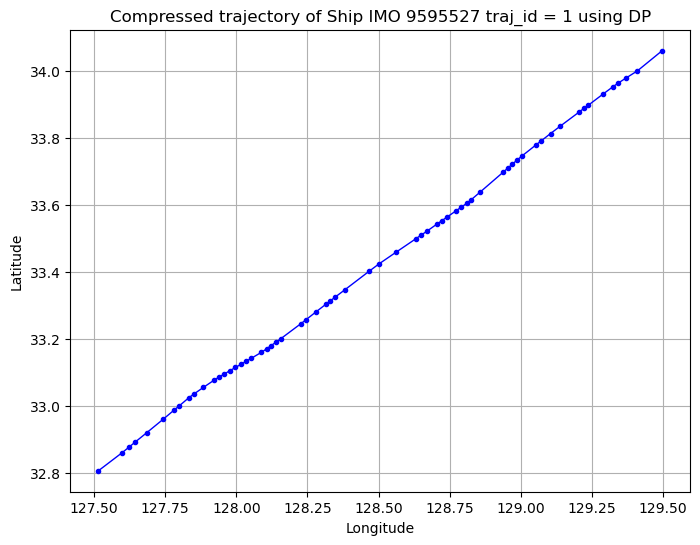

In [9]:
# Set epsilon threshold (e.g., 0.0001 degrees approx. 10 meters, depending on latitude)
epsilon_deg = 0.0001 
df_compressed = douglas_peucker_compression(df_traj_1, epsilon_deg)

# Plot the ship trajectory (Lat vs Lng)
plt.figure(figsize=(8, 6))
plt.plot(df_compressed['Lng'], df_compressed['Lat'], marker='o', markersize=3, linewidth=1, color='blue')

# Add title and labels
plt.title('Compressed trajectory of Ship IMO 9595527 traj_id = 1 using DP', fontsize=12)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.grid(True)
plt.show()

## Trajectory Compression Based on the Top-Down Time-Ratio (TD-TR) Algorithm

### Overview
This code implements a **time-aware trajectory compression method** for AIS vessel data based on the **Top-Down Time-Ratio (TD-TR) algorithm**.  
Unlike purely geometry-based approaches, this method explicitly incorporates temporal information, ensuring that the compressed trajectory preserves both **spatial shape** and **kinematic consistency**.

### Core Idea
The TD-TR algorithm evaluates trajectory deviation using the **Synchronized Euclidean Distance (SED)**.  
SED measures the distance between the actual vessel position at a given time and its **time-synchronized projected position**, assuming constant velocity motion between two anchor points. This allows the algorithm to account for irregular sampling intervals, which are common in AIS data.

### Key Components

#### Synchronized Euclidean Distance (SED)
The function `synchronized_euclidean_distance` computes the deviation of intermediate points from a linearly interpolated trajectory in **both space and time**:
- The projected position is obtained by linear interpolation between the start and end points based on the relative time ratio.
- The Euclidean distance between the actual and projected positions defines the SED.
- This formulation ensures that points with significant kinematic deviation are correctly identified, even if geometric deviation alone is small.

#### Recursive Top-Down Compression
The function `tdtr_compression` applies a recursive **top-down segmentation strategy**:
- The first and last trajectory points act as temporal–spatial anchors.
- Intermediate points are evaluated using SED.
- If the maximum SED exceeds a given threshold, the trajectory is split at that point and processed recursively.
- If not, all intermediate points are discarded, retaining only the anchor points.

This recursive structure mirrors the Douglas–Peucker algorithm but replaces geometric distance with a time-synchronized metric.

### Inputs and Outputs
- **Input**:
  - A pandas DataFrame containing AIS data with `Lat`, `Lng`, and `Date/Time` fields.
  - A threshold `epsilon` defining the maximum allowable SED.
- **Output**:
  - A compressed pandas DataFrame that retains critical trajectory points while preserving original attributes and chronological order.

### Practical Notes
- Time information is converted to Unix timestamps to enable continuous interpolation.
- The compression threshold `epsilon` shares the same unit as the spatial


In [10]:
import numpy as np
import pandas as pd

def synchronized_euclidean_distance(points, times, start_point, end_point, start_time, end_time):
    """
    Calculates the Synchronized Euclidean Distance (SED) for a set of points.
    
    Mathematical Formulation:
    The SED measures the distance between the actual position of a vessel at time t
    and its projected position assuming constant velocity between the start and end points.
    
    Projected Position P_hat(t) = P_start + (P_end - P_start) * (t - t_start) / (t_end - t_start)
    SED = || P_actual(t) - P_hat(t) ||
    
    Parameters:
    - points: np.array, shape (N, 2), coordinates (Lat, Lng) of intermediate points.
    - times: np.array, shape (N,), timestamps (e.g., unix epoch) of intermediate points.
    - start_point: np.array, shape (2,), (Lat, Lng) of the start anchor.
    - end_point: np.array, shape (2,), (Lat, Lng) of the end anchor.
    - start_time: float, timestamp of the start anchor.
    - end_time: float, timestamp of the end anchor.
    
    Returns:
    - distances: np.array, shape (N,), the SED for each point.
    """
    # Avoid division by zero if time duration is zero (duplicate timestamps)
    time_span = end_time - start_time
    if time_span == 0:
        return np.linalg.norm(points - start_point, axis=1)

    # 1. Calculate the Time Ratio (ratio of elapsed time to total duration)
    # Shape: (N,)
    ratio = (times - start_time) / time_span
    
    # 2. Calculate Projected Positions (Linear Interpolation in Time)
    # Using broadcasting: Start + (Vector * Ratio)
    # shape of vector: (2,) -> needs to broadcast to (N, 2)
    vector = end_point - start_point
    
    # We reshape ratio to (N, 1) to multiply with vector (2,)
    projected_points = start_point + vector * ratio[:, np.newaxis]
    
    # 3. Calculate Euclidean Distance between Actual and Projected
    distances = np.linalg.norm(points - projected_points, axis=1)
    
    return distances

def tdtr_compression(df, epsilon):
    """
    Compresses a vessel trajectory using the Top-Down Time-Ratio (TD-TR) algorithm.
    
    Parameters:
    - df: pd.DataFrame, must contain 'Lat', 'Lng', and 'Date/Time'.
    - epsilon: float, the maximum SED threshold (same unit as coordinates, e.g., degrees).
      
    Returns:
    - df_compressed: pd.DataFrame, the compressed trajectory preserving kinematic integrity.
    """
    # 1. Data Preparation
    # Convert 'Date/Time' to Unix timestamp (seconds) for mathematical interpolation
    # Ensure we work with a copy to avoid SettingWithCopyWarning on original data
    data = df.copy()
    data['timestamp'] = pd.to_datetime(data['Date/Time']).astype(int) / 10**9
    
    # Extract arrays for efficient computation
    # Columns: 0:Lat, 1:Lng, 2:Timestamp
    points_matrix = data[['Lat', 'Lng', 'timestamp']].values
    
    # 2. Recursive Function
    def recursive_tdtr(mat, threshold):
        dmax = 0.0
        index = 0
        end = len(mat) - 1
        
        # Base case
        if end < 2:
            return mat
            
        # Unpack start and end anchors
        start_pt = mat[0, :2] # Lat, Lng
        start_t = mat[0, 2]   # Timestamp
        
        end_pt = mat[end, :2]
        end_t = mat[end, 2]
        
        # Get intermediate points and times
        # mat[1:-1, :2] gets Lat/Lng rows 1 to end-1
        # mat[1:-1, 2] gets Timestamp rows 1 to end-1
        inter_pts = mat[1:-1, :2]
        inter_times = mat[1:-1, 2]
        
        # Calculate SED
        dists = synchronized_euclidean_distance(
            inter_pts, inter_times, start_pt, end_pt, start_t, end_t
        )
        
        if len(dists) > 0:
            dmax = dists.max()
            index = dists.argmax() + 1
            
        # Decision Logic (Identical structure to DP)
        if dmax >= threshold:
            left_results = recursive_tdtr(mat[:index+1], threshold)
            right_results = recursive_tdtr(mat[index:], threshold)
            return np.vstack((left_results[:-1], right_results))
        else:
            return np.vstack((mat[0], mat[end]))

    # 3. Execute Algorithm
    compressed_array = recursive_tdtr(points_matrix, epsilon)
    
    # 4. Restore DataFrame
    # Convert results back to DF. We use Lat, Lng, and Timestamp to match.
    # Note: We rely on Timestamp for uniqueness here, which is safer than coordinates alone.
    df_temp = pd.DataFrame(compressed_array, columns=['Lat', 'Lng', 'timestamp'])
    
    # Convert timestamp back to datetime objects for merging/display if needed, 
    # but for merging, the float timestamp is precise.
    
    # Merge to get original columns (SOG, COG, etc.)
    # We join on 'timestamp' as it is a unique identifier for the row in this context
    df_compressed = pd.merge(
        data, 
        df_temp[['timestamp']], # Only need timestamp to filter keys
        on='timestamp', 
        how='inner'
    )
    
    # Clean up auxiliary column
    df_compressed = df_compressed.drop(columns=['timestamp'])
    
    return df_compressed.sort_values(by='Date/Time').reset_index(drop=True)

# ==========================================
# Example Usage
# ==========================================

# Using the same threshold as the DP example for comparison
epsilon_deg = 0.0001 

df_compressed_tdtr = tdtr_compression(df_traj_1, epsilon_deg)

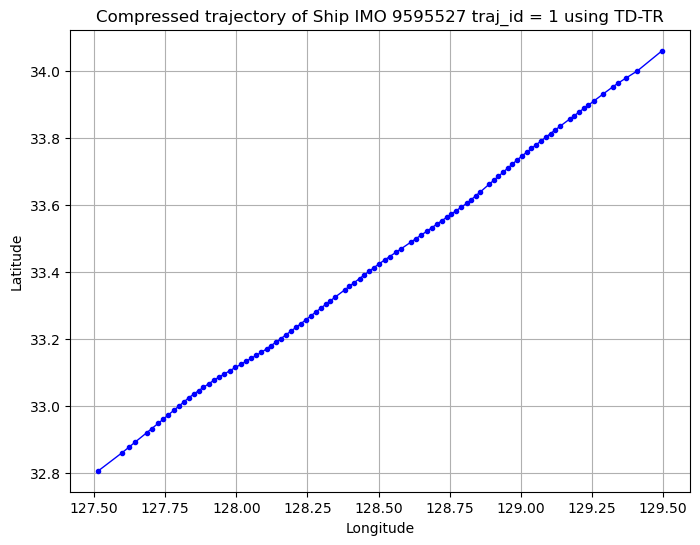

In [11]:
# Plot the ship trajectory (Lat vs Lng)
plt.figure(figsize=(8, 6))
plt.plot(df_compressed_tdtr['Lng'], df_compressed_tdtr['Lat'], marker='o', markersize=3, linewidth=1, color='blue')

# Add title and labels
plt.title('Compressed trajectory of Ship IMO 9595527 traj_id = 1 using TD-TR', fontsize=12)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.grid(True)
plt.show()

## Trajectory Similarity Measurement Using the Hausdorff Distance

### Overview
This code provides a quantitative method to measure the **spatial dissimilarity between two AIS vessel trajectories** using the **Hausdorff Distance**.  
The Hausdorff Distance captures the maximum deviation between two trajectories and is widely used to evaluate trajectory similarity, shape consistency, and compression quality.

### Core Idea
The Hausdorff Distance evaluates how far two point sets are from each other by considering the **worst-case nearest-point distance**.  
For two trajectories \( A \) and \( B \), the symmetric Hausdorff Distance is defined as the maximum of the two directed distances:
- from trajectory \( A \) to \( B \),
- and from trajectory \( B \) to \( A \).

This formulation ensures that discrepancies in either trajectory are fully captured.

### Key Components

#### Haversine Distance Matrix
The function `haversine_distance_matrix` computes the **pairwise great-circle distances** between all points in two trajectories:
- Geographic coordinates (latitude and longitude) are converted from degrees to radians.
- The Haversine formula is applied to account for Earth’s curvature.
- Vectorized broadcasting is used to efficiently generate an \( N \times M \) distance matrix in meters.

This step provides the fundamental distance information required for trajectory comparison.

#### Hausdorff Distance Computation
The function `calculate_hausdorff_distance` computes the **symmetric Hausdorff Distance**:
- For each point in the first trajectory, the nearest point in the second trajectory is identified.
- The maximum of these nearest-neighbor distances defines the directed Hausdorff distance.
- The process is repeated in the opposite direction.
- The final Hausdorff Distance is the maximum of the two directed distances.

This ensures robustness against unequal sampling densities and asymmetric deviations.

### Inputs and Outputs
- **Input**:
  - Two pandas DataFrames representing vessel trajectories, each containing `Lat` and `Lng` fields.
- **Output**:
  - A single scalar value representing the symmetric Hausdorff Distance between the two trajectories, expressed in meters.

### Practical Notes
- This distance metric is sensitive to outliers, making it suitable for detecting extreme deviations between trajectories.
- It is commonly used to evaluate the fidelity of trajectory compression algorithms and to compare vessel paths under different operational or environmental conditions.

Overall, this implementation offers a rigorous and interpretable tool for AIS trajectory similarity analysis in geospatial and maritime applications.


In [12]:
def haversine_distance_matrix(traj1, traj2):
    """
    Computes the pairwise Haversine distance matrix between two sets of coordinates.
    
    Parameters:
    - traj1: np.array, shape (N, 2), coordinates (Lat, Lng) of trajectory 1.
    - traj2: np.array, shape (M, 2), coordinates (Lat, Lng) of trajectory 2.
    
    Returns:
    - dist_matrix: np.array, shape (N, M), matrix where [i, j] is the distance 
      between point i of traj1 and point j of traj2 in meters.
    """
    # Earth radius in meters
    R = 6371000.0
    
    # Convert degrees to radians for trigonometric functions
    # Shape: (N, 1, 2) and (1, M, 2) to enable broadcasting
    rad1 = np.radians(traj1)[:, np.newaxis, :]
    rad2 = np.radians(traj2)[np.newaxis, :, :]
    
    # Extract Lat and Lng
    # lat1: (N, 1), lat2: (1, M)
    lat1, lng1 = rad1[:, :, 0], rad1[:, :, 1]
    lat2, lng2 = rad2[:, :, 0], rad2[:, :, 1]
    
    # Haversine formula
    dlat = lat2 - lat1
    dlng = lng2 - lng1
    
    a = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlng / 2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
    
    return R * c

def calculate_hausdorff_distance(df1, df2):
    """
    Calculates the symmetric Hausdorff Distance between two vessel trajectories.
    
    Mathematical Formulation:
    H(A, B) = max(h(A, B), h(B, A))
    where h(A, B) = max_{a in A} min_{b in B} d(a, b)
    
    Parameters:
    - df1: pd.DataFrame, trajectory 1 containing 'Lat' and 'Lng'.
    - df2: pd.DataFrame, trajectory 2 containing 'Lat' and 'Lng'.
    
    Returns:
    - hausdorff_dist: float, the symmetric Hausdorff distance in meters.
    """
    # 1. Extract coordinates as NumPy arrays
    # Ensure we use .values to get the underlying numpy array for speed
    p1 = df1[['Lat', 'Lng']].values
    p2 = df2[['Lat', 'Lng']].values
    
    # 2. Compute the full Distance Matrix (N x M)
    # This matrix contains the distance from every point in T1 to every point in T2
    # Using Haversine to account for Earth's curvature
    D = haversine_distance_matrix(p1, p2)
    
    # 3. Calculate Directed Hausdorff Distances
    
    # h(T1, T2): For every point in T1, find nearest in T2 (min), then take max of those
    # Axis 1 represents T2, so min(axis=1) gives nearest neighbor in T2 for each point in T1
    directed_1_to_2 = np.max(np.min(D, axis=1))
    
    # h(T2, T1): For every point in T2, find nearest in T1 (min), then take max of those
    # Axis 0 represents T1
    directed_2_to_1 = np.max(np.min(D, axis=0))
    
    # 4. Calculate Symmetric Hausdorff Distance
    hausdorff_dist = max(directed_1_to_2, directed_2_to_1)
    
    return hausdorff_dist

In [13]:
dist_meters = calculate_hausdorff_distance(df_traj_1, df_traj_2)
dist_meters

35838.33400237029

## Trajectory Similarity Measurement Using the Discrete Fréchet Distance

### Overview
This code implements the **Discrete Fréchet Distance** to quantify the similarity between two AIS vessel trajectories.  
Compared with pointwise or set-based distance measures, the Fréchet Distance explicitly considers the **ordering and continuity** of trajectory points, making it particularly suitable for comparing movement paths with temporal progression.

### Core Idea
The Fréchet Distance intuitively represents the minimum required “leash length” for two walkers traversing two trajectories from start to end, without backtracking.  
It captures not only spatial proximity but also the **coupled progression along each trajectory**, ensuring that corresponding segments are compared in a consistent order.

In this implementation, the **discrete version** of the Fréchet Distance is computed using **dynamic programming**, which is well-suited for AIS trajectories sampled at discrete time intervals.

### Key Components

#### Haversine Distance Matrix
The function `haversine_distance_matrix` computes the pairwise **great-circle distances** between all points of two trajectories:
- Latitude and longitude are converted to radians.
- The Haversine formula accounts for Earth’s curvature.
- Vectorized broadcasting efficiently constructs an \( N \times M \) distance matrix in meters.

This matrix serves as the cost basis for the Fréchet Distance calculation.

#### Dynamic Programming Formulation
The function `calculate_frechet_distance` evaluates the Discrete Fréchet Distance through a coupling matrix:
- Each entry represents the minimum possible maximum distance encountered when matching trajectory prefixes.
- The recurrence relation ensures that the worst-case deviation along the matched paths is minimized.
- Three admissible transitions are considered: advancing in one trajectory, the other, or both simultaneously.

The final Fréchet Distance is obtained from the bottom-right corner of the dynamic programming table.

### Inputs and Outputs
- **Input**:
  - Two pandas DataFrames representing AIS trajectories, each containing `Lat` and `Lng` fields.
- **Output**:
  - A single scalar value representing the Discrete Fréchet Distance between the two trajectories, expressed in meters.

### Practical Notes
- The Fréchet Distance is sensitive to trajectory ordering and is therefore more restrictive than Hausdorff Distance.
- It is especially useful for evaluating trajectory similarity in applications such as route comparison, maneuver analysis, and validation of trajectory compression methods.

This implementation provides a rigorous and order-aware similarity metric for AIS trajectory analysis in maritime data processing workflows.


In [14]:
def haversine_distance_matrix(traj1, traj2):
    """
    Computes the pairwise Haversine distance matrix between two sets of coordinates.
    (Same helper function as used in Hausdorff calculation).
    
    Returns:
    - dist_matrix: np.array, shape (N, M) in meters.
    """
    R = 6371000.0 # Earth radius in meters
    rad1 = np.radians(traj1)[:, np.newaxis, :]
    rad2 = np.radians(traj2)[np.newaxis, :, :]
    
    lat1, lng1 = rad1[:, :, 0], rad1[:, :, 1]
    lat2, lng2 = rad2[:, :, 0], rad2[:, :, 1]
    
    dlat = lat2 - lat1
    dlng = lng2 - lng1
    
    a = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlng / 2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
    
    return R * c

def calculate_frechet_distance(df1, df2):
    """
    Calculates the Discrete Frechet Distance between two vessel trajectories.
    
    Mathematical Formulation:
    The problem is solved using Dynamic Programming.
    Let ca[i, j] be the minimum bottleneck distance to couple the trajectory 
    segments T1[0...i] and T2[0...j].
    
    Recurrence:
    ca[i, j] = max( d(T1[i], T2[j]), min(ca[i-1, j], ca[i, j-1], ca[i-1, j-1]) )
    
    Parameters:
    - df1: pd.DataFrame, trajectory 1 containing 'Lat' and 'Lng'.
    - df2: pd.DataFrame, trajectory 2 containing 'Lat' and 'Lng'.
    
    Returns:
    - frechet_dist: float, the Frechet distance in meters.
    """
    # 1. Data Preparation
    p1 = df1[['Lat', 'Lng']].values
    p2 = df2[['Lat', 'Lng']].values
    
    n, m = len(p1), len(p2)
    
    # 2. Compute Distance Matrix (Cost Matrix)
    # dist_matrix[i, j] is the physical distance between p1[i] and p2[j]
    dist_matrix = haversine_distance_matrix(p1, p2)
    
    # 3. Initialize the Coupling Matrix (DP Table)
    # ca (Coupling Array) stores the Frechet distance up to indices i, j
    ca = np.zeros((n, m))
    ca.fill(-1.0)
    
    # 4. Fill Base Cases
    # Corner case: The start of both trajectories
    ca[0, 0] = dist_matrix[0, 0]
    
    # First column: We can only come from directly above (i-1, 0)
    for i in range(1, n):
        ca[i, 0] = max(dist_matrix[i, 0], ca[i-1, 0])
        
    # First row: We can only come from the left (0, j-1)
    for j in range(1, m):
        ca[0, j] = max(dist_matrix[0, j], ca[0, j-1])
        
    # 5. Fill Remaining Cells (Dynamic Programming)
    for i in range(1, n):
        for j in range(1, m):
            # To reach state (i, j), we must have come from:
            # (i-1, j)   -> Walker 1 moved, Walker 2 stayed
            # (i, j-1)   -> Walker 1 stayed, Walker 2 moved
            # (i-1, j-1) -> Both moved simultaneously
            
            min_prev = min(ca[i-1, j], ca[i, j-1], ca[i-1, j-1])
            
            # The cost is the max of the current distance and the bottleneck to get here
            ca[i, j] = max(dist_matrix[i, j], min_prev)
            
    # 6. The result is the value in the bottom-right corner
    return ca[n-1, m-1]

In [15]:
frechet_dist_meters = calculate_frechet_distance(df_traj_1, df_traj_2)

print(f"Frechet Distance: {frechet_dist_meters:.2f} meters")

Frechet Distance: 35838.33 meters


## Trajectory Similarity Measurement Using Dynamic Time Warping (DTW)

### Overview
This code implements **Dynamic Time Warping (DTW)** to measure the similarity between two AIS vessel trajectories.  
DTW is designed to compare sequences that may differ in length or sampling rate by allowing **non-linear alignment in time**, making it particularly suitable for AIS data with irregular reporting intervals.

### Core Idea
Dynamic Time Warping identifies an **optimal alignment path** between two trajectories that minimizes the cumulative spatial distance while preserving the order of points.  
Unlike strict point-to-point matching, DTW permits stretching and compression along the time axis, enabling meaningful comparison of trajectories executed at different speeds or with varying sampling densities.

### Key Components

#### Haversine Distance Matrix
The function `haversine_distance_matrix` computes the pairwise **great-circle distances** between all points in two trajectories:
- Geographic coordinates are converted from degrees to radians.
- The Haversine formula accounts for Earth’s curvature.
- Vectorized broadcasting is used to efficiently generate a distance matrix in meters.

This matrix defines the local matching cost between trajectory points.

#### Dynamic Programming for DTW
The function `calculate_dtw_distance` computes the DTW distance using dynamic programming:
- An accumulated cost matrix is initialized with infinite values to handle boundary conditions.
- Each cell represents the minimum cumulative cost to align the two trajectory prefixes up to that point.
- Three transition options are considered at each step: insertion, deletion, and match.
- The final DTW distance corresponds to the accumulated cost at the bottom-right corner of the matrix.

### Inputs and Outputs
- **Input**:
  - Two pandas DataFrames representing AIS trajectories, each containing `Lat` and `Lng` fields.
- **Output**:
  - A single scalar value representing the DTW distance between the two trajectories, expressed in meters.

### Practical Notes
- DTW focuses on cumulative similarity rather than worst-case deviation, in contrast to Hausdorff or Fréchet distances.
- It is especially effective for comparing vessel routes with similar spatial patterns but different traversal speeds.
- For long trajectories, DTW can be computationally expensive; window constraints or downsampling may be applied in practice.

This DTW-based implementation provides a flexible and robust similarity metric for AIS trajectory comparison and analysis.

In [16]:
def haversine_distance_matrix(traj1, traj2):
    """
    Computes the pairwise Haversine distance matrix.
    (Reusable helper function from previous examples).
    
    Returns:
    - dist_matrix: np.array, shape (N, M) in meters.
    """
    R = 6371000.0
    rad1 = np.radians(traj1)[:, np.newaxis, :]
    rad2 = np.radians(traj2)[np.newaxis, :, :]
    
    lat1, lng1 = rad1[:, :, 0], rad1[:, :, 1]
    lat2, lng2 = rad2[:, :, 0], rad2[:, :, 1]
    
    dlat = lat2 - lat1
    dlng = lng2 - lng1
    
    a = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlng / 2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
    
    return R * c

def calculate_dtw_distance(df1, df2):
    """
    Calculates the Dynamic Time Warping (DTW) distance between two vessel trajectories.
    
    Mathematical Formulation:
    DTW finds the optimal alignment path W to minimize the cumulative cost.
    D(i, j) = d(p1_i, p2_j) + min( D(i-1, j), D(i, j-1), D(i-1, j-1) )
    
    Parameters:
    - df1: pd.DataFrame, trajectory 1 containing 'Lat' and 'Lng'.
    - df2: pd.DataFrame, trajectory 2 containing 'Lat' and 'Lng'.
    
    Returns:
    - dtw_cost: float, the cumulative warping distance in meters.
    """
    # 1. Data Preparation
    p1 = df1[['Lat', 'Lng']].values
    p2 = df2[['Lat', 'Lng']].values
    
    n, m = len(p1), len(p2)
    
    # 2. Compute Distance Matrix (Cost Matrix)
    # dist_matrix[i, j] is the physical distance between p1[i] and p2[j]
    dist_matrix = haversine_distance_matrix(p1, p2)
    
    # 3. Initialize Accumulated Cost Matrix (DTW Matrix)
    # We use size (n+1, m+1) and fill with infinity to handle boundary conditions easily
    dtw_matrix = np.full((n + 1, m + 1), np.inf)
    
    # The starting condition: cost is 0 before we begin matching points
    dtw_matrix[0, 0] = 0
    
    # 4. Fill Matrix (Dynamic Programming)
    # We iterate from 1 to n/m because row 0 and col 0 are padding (infinity)
    for i in range(1, n + 1):
        for j in range(1, m + 1):
            # Current local cost (distance between points)
            # Note: dist_matrix is 0-indexed, so we access [i-1, j-1]
            cost = dist_matrix[i-1, j-1]
            
            # Recurrence relation:
            # We take the current cost plus the minimum of the three possible predecessors:
            # 1. dtw_matrix[i-1, j]   -> Insertion (warp time in traj1)
            # 2. dtw_matrix[i, j-1]   -> Deletion (warp time in traj2)
            # 3. dtw_matrix[i-1, j-1] -> Match (advance both)
            
            dtw_matrix[i, j] = cost + min(
                dtw_matrix[i-1, j],    
                dtw_matrix[i, j-1],    
                dtw_matrix[i-1, j-1]   
            )
            
    # 5. The result is the value in the bottom-right corner
    # This represents the total cumulative distance of the optimal warping path.
    return dtw_matrix[n, m]

In [17]:
dtw_meters = calculate_dtw_distance(df_traj_1, df_traj_2)

print(f"DTW Distance: {dtw_meters:.2f} meters (Cumulative)")

DTW Distance: 604589.03 meters (Cumulative)


## Trajectory Similarity Measurement Using Longest Common Subsequence (LCSS)

### Overview
This code implements the **Longest Common Subsequence (LCSS) similarity** to compare two AIS vessel trajectories.  
LCSS focuses on identifying the longest sequence of spatially corresponding points shared by two trajectories while **tolerating noise, outliers, and partial mismatches**, which are common in real-world AIS data.

### Core Idea
The LCSS approach treats trajectory comparison as a **sequence matching problem** rather than a strict distance minimization task.  
Two trajectory points are considered a match if their geographic distance is within a predefined spatial threshold. The similarity is then defined as the proportion of matched points relative to the shorter trajectory.

By allowing unmatched points to be skipped, LCSS provides robustness against missing data, irregular sampling, and local deviations.

### Key Components

#### Haversine Distance Matrix
The function `haversine_distance_matrix` computes the pairwise **great-circle distances** between all points in the two trajectories:
- Latitude and longitude are converted to radians.
- The Haversine formula accounts for Earth’s curvature.
- The resulting distance matrix (in meters) is used to determine whether two points are spatially close enough to be considered a match.

#### Dynamic Programming for LCSS
The function `calculate_lcss_similarity` applies dynamic programming to compute the LCSS length:
- A score matrix stores the length of the longest common subsequence up to each pair of trajectory prefixes.
- If the distance between two points is below the threshold `epsilon`, the subsequence is extended.
- Otherwise, the best score from previous states is propagated forward.
- The final LCSS length is normalized by the length of the shorter trajectory to obtain a similarity score in the range \([0, 1]\).

### Inputs and Outputs
- **Input**:
  - Two pandas DataFrames representing AIS trajectories, each containing `Lat` and `Lng` fields.
  - A spatial threshold `epsilon` (in meters) defining when two points are considered a match.
- **Output**:
  - A scalar similarity score between 0.0 and 1.0, where higher values indicate greater trajectory similarity.

### Practical Notes
- The choice of `epsilon` strongly influences the similarity result and should be selected based on spatial resolution and application requirements.
- LCSS is less sensitive to outliers than Hausdorff or DTW and is well suited for partial trajectory matching.
- This method is particularly useful for route similarity analysis, anomaly detection, and clustering of AIS trajectories.

This LCSS-based similarity metric provides a flexible and noise-tolerant approach to AIS trajectory comparison.



In [18]:
def haversine_distance_matrix(traj1, traj2):
    """
    Computes the pairwise Haversine distance matrix.
    (Reusable helper function).
    
    Returns:
    - dist_matrix: np.array, shape (N, M) in meters.
    """
    R = 6371000.0
    rad1 = np.radians(traj1)[:, np.newaxis, :]
    rad2 = np.radians(traj2)[np.newaxis, :, :]
    
    lat1, lng1 = rad1[:, :, 0], rad1[:, :, 1]
    lat2, lng2 = rad2[:, :, 0], rad2[:, :, 1]
    
    dlat = lat2 - lat1
    dlng = lng2 - lng1
    
    a = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlng / 2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
    
    return R * c

def calculate_lcss_similarity(df1, df2, epsilon):
    """
    Calculates the Longest Common Subsequence (LCSS) Similarity between two trajectories.
    
    Mathematical Formulation:
    L(i, j) = 
      0                               if i=0 or j=0
      1 + L(i-1, j-1)                 if dist(p1_i, p2_j) < epsilon
      max(L(i-1, j), L(i, j-1))       otherwise
      
    Similarity = L(n, m) / min(n, m)
    
    Parameters:
    - df1: pd.DataFrame, trajectory 1 containing 'Lat' and 'Lng'.
    - df2: pd.DataFrame, trajectory 2 containing 'Lat' and 'Lng'.
    - epsilon: float, the matching threshold in METERS.
    
    Returns:
    - lcss_score: float, a value between 0.0 and 1.0. 
      (1.0 means trajectories are sub-segments of each other within threshold).
    """
    # 1. Data Preparation
    p1 = df1[['Lat', 'Lng']].values
    p2 = df2[['Lat', 'Lng']].values
    
    n, m = len(p1), len(p2)
    
    # 2. Compute Distance Matrix
    dist_matrix = haversine_distance_matrix(p1, p2)
    
    # 3. Initialize LCSS Matrix (Score Matrix)
    # Size (n+1, m+1) filled with zeros
    lcss_matrix = np.zeros((n + 1, m + 1), dtype=int)
    
    # 4. Fill Matrix (Dynamic Programming)
    for i in range(1, n + 1):
        for j in range(1, m + 1):
            # Check if the physical distance is within the threshold epsilon
            if dist_matrix[i-1, j-1] < epsilon:
                # Match found: extend the subsequence length by 1
                lcss_matrix[i, j] = 1 + lcss_matrix[i-1, j-1]
            else:
                # No match: carry forward the best previous score (skip point)
                lcss_matrix[i, j] = max(lcss_matrix[i-1, j], lcss_matrix[i, j-1])
                
    # 5. Normalize the Score
    # The raw LCSS count represents the number of matching points.
    # We normalize by the length of the shorter trajectory to get a 0-1 ratio.
    longest_common_len = lcss_matrix[n, m]
    lcss_score = longest_common_len / min(n, m)
    
    return lcss_score

In [19]:
epsilon_meters = 500.0
lcss_ratio = calculate_lcss_similarity(df_traj_1, df_traj_2, epsilon_meters)

print(f"LCSS Similarity Score: {lcss_ratio:.4f}")

LCSS Similarity Score: 0.0588


## Spatial Point Density Estimation Using Grid-Based Partitioning

### Overview
This code implements a **grid-based spatial aggregation method** to analyze the distribution of AIS position reports within a specified geographic region.  
By partitioning the study area into regular grid cells and counting the number of AIS points in each cell, the method provides a straightforward representation of **spatial point density**, which is commonly used for traffic intensity analysis and heatmap visualization.

### Core Idea
The study area is discretized into a two-dimensional grid defined by latitude and longitude boundaries.  
Each AIS position is assigned to a corresponding grid cell, and the total number of points within each cell is counted. The resulting matrix captures the spatial concentration of vessel activity across the region.

This approach emphasizes **point frequency rather than physical density**, which is generally sufficient for exploratory analysis and visualization of AIS traffic patterns.

### Key Components

#### Area Filtering and Grid Definition
Only AIS points located within the specified latitude and longitude bounds are retained.  
The study region is then divided into evenly spaced bins along both latitude and longitude directions, forming a regular grid.

#### Grid Index Assignment
Each AIS point is mapped to a grid cell using bin indices derived from its geographic coordinates:
- Longitude values determine the column index.
- Latitude values determine the row index.
Boundary checks ensure all indices remain within valid grid limits.

#### Density Matrix Construction
The number of points in each grid cell is computed using group-based counting.  
These counts are then placed into a two-dimensional matrix, where each entry represents the point count of a corresponding spatial cell.

### Inputs and Outputs
- **Input**:
  - A pandas DataFrame containing AIS position data with `Lat` and `Lng` fields.
  - Geographic bounds of the study area and the desired grid resolution.
- **Output**:
  - A two-dimensional array representing point counts per grid cell.
  - Latitude and longitude bin boundaries defining the grid structure.

### Practical Notes
- The resulting matrix represents point counts, not area-normalized density. For strict density calculations, latitude-dependent area corrections would be required.
- When visualizing the matrix as a heatmap, axis orientation should be handled carefully to ensure latitude increases in the correct direction.
- This method is well suited for identifying high-traffic corridors, anchorage areas, and spatial clustering of AIS data.

Overall, this grid-based point density estimation provides an intuitive and efficient tool for spatial analysis of AIS vessel movements.


In [20]:
def calculate_point_density(df, lat_min, lat_max, lng_min, lng_max, grid_size):
    """
    Partitions the AIS data into a grid covering the specified area and 
    calculates the point count (density) for each grid cell.

    Parameters:
    - df (pd.DataFrame): DataFrame containing 'Lat' and 'Lng' columns.
    - lat_min (float): Minimum latitude of the study area.
    - lat_max (float): Maximum latitude of the study area.
    - lng_min (float): Minimum longitude of the study area.
    - lng_max (float): Maximum longitude of the study area.
    - grid_size (int): Number of grid cells along the latitude and longitude directions.

    Returns:
    - density_matrix (np.ndarray): A grid_size x grid_size 2D array representing the point count per cell.
    - lat_bins (np.ndarray): Grid boundaries in the latitude direction.
    - lng_bins (np.ndarray): Grid boundaries in the longitude direction.
    """
    
    # 1. Filter points within the defined area
    df_filtered = df[
        (df['Lat'] >= lat_min) & (df['Lat'] <= lat_max) &
        (df['Lng'] >= lng_min) & (df['Lng'] <= lng_max)
    ].copy()
    
    # 2. Define grid boundaries (bins)
    lat_bins = np.linspace(lat_min, lat_max, grid_size + 1)
    lng_bins = np.linspace(lng_min, lng_max, grid_size + 1)
    
    # The calculation here focuses on Point Count.
    # To calculate strict "density" (Count/Area), one would need to account for area differences 
    # due to changing latitude. For visualization (heatmap), the point count is usually sufficient.
    
    # 3. Calculate the grid index (i and j) for each point
    # np.digitize() returns the index of the bin the value belongs to.
    # Index i (Longitude)
    # Subtract 1 because np.digitize returns an index starting from 1 (right boundary).
    df_filtered['lng_idx'] = np.digitize(df_filtered['Lng'], lng_bins) - 1
    # Index j (Latitude)
    df_filtered['lat_idx'] = np.digitize(df_filtered['Lat'], lat_bins) - 1
    
    # 4. Ensure indices are within the valid range [0, grid_size - 1]
    df_filtered['lng_idx'] = df_filtered['lng_idx'].clip(0, grid_size - 1)
    df_filtered['lat_idx'] = df_filtered['lat_idx'].clip(0, grid_size - 1)
    
    # 5. Count the number of points in each grid cell (Point Count)
    density_df = df_filtered.groupby(['lat_idx', 'lng_idx']).size().reset_index(name='point_count')
    
    # 6. Convert the results into a grid_size x grid_size 2D matrix
    density_matrix = np.zeros((grid_size, grid_size))
    
    for _, row in density_df.iterrows():
        # Note: In matplotlib/seaborn heatmaps, the Y-axis index (lat_idx here) is typically the row index,
        # and the X-axis index (lng_idx here) is the column index.
        density_matrix[row['lat_idx'], row['lng_idx']] = row['point_count']
        
    # Note on orientation: To ensure latitude (Y-axis) increases from bottom (lat_min) to top (lat_max) 
    # when plotting the heatmap, the matrix might need to be flipped vertically 
    # (or the Y-axis ticks need to be reversed). We keep the matrix as is (lat_idx=0 is row 0) 
    # and handle the Y-axis direction during the plotting phase (using reversed labels or np.flipud).
    
    return density_matrix, lat_bins, lng_bins

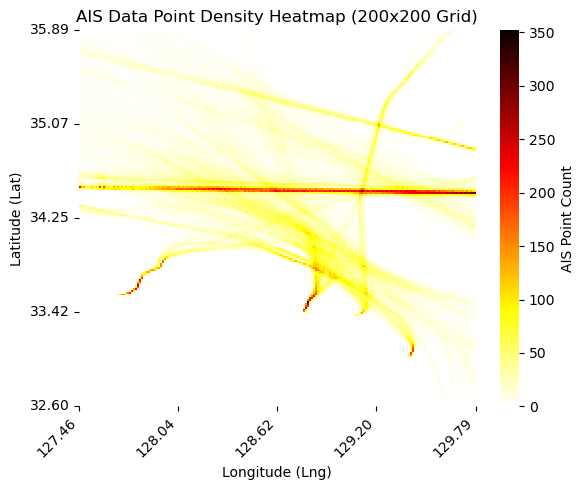


Grid Density Matrix Shape: (200, 200)
Total Points in Grid: 428341.0
Max Point Count in any Grid Cell: 352.0


In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

# --- Define Parameters and Data Preprocessing (Assuming 'df' is loaded) ---
# Define area boundaries
lat_min = 32.60190
lat_max = 35.88860
lng_min = 127.45671
lng_max = 129.78582

# Define grid resolution (e.g., dividing the area into a 100x100 grid)
# Adjust based on data sparsity and required detail level
grid_size = 200

# 1. Calculate Point Density
# ⚠️ Ensure the 'df' DataFrame (containing AIS data) is available when running this code.
density_matrix, lat_bins, lng_bins = calculate_point_density(
    df, lat_min, lat_max, lng_min, lng_max, grid_size
)

# 2. Plotting the Heatmap
plt.figure(figsize=(6, 5))

# Use seaborn to draw the heatmap
# 'density_matrix' row index corresponds to 'lat_idx', column index to 'lng_idx'.
# lat_idx=0 corresponds to lat_min (lowest latitude).
ax = sns.heatmap(
    density_matrix, 
    cmap="hot_r",  # Color scheme: 'hot_r' indicates high density with brighter colors
    # Color bar label is set here
    cbar_kws={'label': 'AIS Point Count'}
)

# Set title and axis labels
ax.set_title(f'AIS Data Point Density Heatmap ({grid_size}x{grid_size} Grid)', fontsize=12)
ax.set_xlabel('Longitude (Lng)', fontsize=10)
ax.set_ylabel('Latitude (Lat)', fontsize=10)

# 3. Customizing Axis Tick Labels to show real geographic coordinates

# We display only a few major ticks, e.g., 5 ticks
num_ticks = 5
# Calculate the step size for placing ticks
lng_tick_step = grid_size // (num_ticks - 1)
lat_tick_step = grid_size // (num_ticks - 1)

# X-axis labels (Longitude)
# We sample from lng_bins to get the boundary values
x_tick_labels = [f'{lng_bins[i]:.2f}' for i in range(0, grid_size + 1, lng_tick_step)]
x_tick_positions = np.arange(0, grid_size + 1, lng_tick_step)

# Y-axis labels (Latitude)
# In the matrix, row 0 (top of the plot) corresponds to lat_max, but lat_bins[0] is lat_min.
# To ensure the Y-axis labels show increasing latitude from bottom to top,
# we need to reverse the order of lat_bins when labeling the ticks, 
# as the heatmap Y-axis is drawn upside down relative to the index mapping.

# Y-axis ticks (Lat_max at the top, Lat_min at the bottom)
y_tick_labels_raw = [f'{lat_bins[i]:.2f}' for i in range(0, grid_size + 1, lat_tick_step)]
y_tick_labels_reversed = y_tick_labels_raw[::-1] # Reverse the labels

y_tick_positions = np.arange(0, grid_size + 1, lat_tick_step)

ax.set_xticks(x_tick_positions)
ax.set_xticklabels(x_tick_labels, rotation=45, ha='right')

ax.set_yticks(y_tick_positions)
# Apply reversed labels to match the matrix orientation on the plot
ax.set_yticklabels(y_tick_labels_reversed) 

# Adjust layout to prevent labels from overlapping
plt.tight_layout()
plt.savefig('point_density_heatmap.png', dpi = 1200)
plt.show()

# Example: View the shape and statistics of the density matrix
print("\nGrid Density Matrix Shape:", density_matrix.shape)
print("Total Points in Grid:", density_matrix.sum())
print("Max Point Count in any Grid Cell:", density_matrix.max())

## Spatial Density Estimation Using Kernel Density Estimation (KDE)

### Overview
This code implements a **Kernel Density Estimation (KDE)** approach to construct a **continuous spatial density field** from discrete AIS position data.  
Compared with grid-based point counting, KDE produces a smooth representation of vessel activity, enabling clearer identification of traffic corridors, hotspots, and spatial patterns.

### Core Idea
Kernel Density Estimation models the spatial distribution of AIS points as a continuous probability density function.  
Each AIS position contributes a smoothly decaying influence to its surrounding area through a kernel function, and the combined effect of all points forms a continuous density surface. The degree of smoothing is controlled by the **bandwidth parameter**.

### Key Components

#### Data Filtering and Preparation
AIS points are first filtered to retain only those within the defined geographic boundaries.  
Coordinates are extracted and arranged in a format suitable for kernel density estimation.

#### KDE Model Construction
A Gaussian kernel is used to estimate the spatial density:
- The `gaussian_kde` function models the underlying density field.
- A user-defined bandwidth parameter controls the spatial smoothness of the resulting density surface.
- Larger bandwidth values yield smoother density fields, while smaller values preserve local detail.

#### Grid Definition and Evaluation
The study area is discretized into a regular grid, and KDE values are evaluated at the **center of each grid cell**:
- Latitude and longitude centers are computed based on grid resolution.
- A mesh grid of evaluation points is constructed.
- KDE is evaluated at all grid centers in a vectorized manner for efficiency.

#### Density Matrix Assembly
The evaluated KDE values are reshaped into a two-dimensional matrix corresponding to the spatial grid.  
This matrix can be directly visualized as a heatmap or contour map to illustrate vessel traffic intensity.

### Inputs and Outputs
- **Input**:
  - A pandas DataFrame containing AIS position data with `Lat` and `Lng` fields.
  - Geographic bounds of the study area.
  - Grid resolution and KDE bandwidth parameter.
- **Output**:
  - A two-dimensional matrix representing KDE-based spatial density values.
  - Latitude and longitude center coordinates corresponding to grid cells.

### Practical Notes
- KDE produces relative density values rather than absolute counts.
- The choice of bandwidth is critical and should reflect the spatial scale of interest and AIS sampling density.
- When visualizing results, attention should be paid to axis orientation to ensure correct geographic interpretation.

This KDE-based method provides a powerful and visually intuitive tool for analyzing and interpreting spatial patterns in AIS vessel movement data.


In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import gaussian_kde # 使用 scipy 库中的优化 KDE 实现

# --- Parameters (Reused from previous request) ---
lat_min = 32.60190
lat_max = 35.88860
lng_min = 127.45671
lng_max = 129.78582
grid_size = 100 
# Bandwidth h is the most consequential parameter.
# Choosing h is critical. For maritime applications, h is often set based on the
# typical width of a shipping lane (e.g., 500 meters to 1 nautical mile).
# 1 nautical mile (approx 1.852 km) is about 0.016 degrees of latitude.
# Let's start with a value h=0.015 degrees (a common starting point for medium resolution).
bandwidth_h = 0.015 


def calculate_kde_density(df, lat_min, lat_max, lng_min, lng_max, grid_size, h):
    """
    Calculates the Kernel Density Estimation (KDE) density field over a grid.
    
    Parameters:
    - df (pd.DataFrame): DataFrame containing 'Lat' and 'Lng' columns.
    - lat_min, lat_max, lng_min, lng_max (float): Area boundaries.
    - grid_size (int): Number of grid cells in each dimension.
    - h (float): Bandwidth (smoothing parameter).
    
    Returns:
    - kde_matrix (np.ndarray): grid_size x grid_size matrix of KDE values.
    - lat_centers (np.ndarray): Latitude centers for the grid cells.
    - lng_centers (np.ndarray): Longitude centers for the grid cells.
    """
    
    # 1. Prepare input data
    # Filter points within the defined area
    df_filtered = df[
        (df['Lat'] >= lat_min) & (df['Lat'] <= lat_max) &
        (df['Lng'] >= lng_min) & (df['Lng'] <= lng_max)
    ].copy()
    
    # Extract coordinates (Lng, Lat)
    data = df_filtered[['Lng', 'Lat']].values.T
    
    if data.shape[1] == 0:
        print("Warning: No data points found in the defined area.")
        return np.zeros((grid_size, grid_size)), np.array([]), np.array([])
        
    # 2. Create the KDE model
    # The gaussian_kde function estimates the PDF using the Gaussian kernel.
    # The 'bw_method' parameter handles the bandwidth. If a scalar h is provided,
    # scipy internally uses it to set the covariance matrix related to the bandwidth.
    # We use a custom bandwidth method that just returns the provided scalar 'h'.
    kde = gaussian_kde(data, bw_method=h)
    
    # 3. Define Grid Centers for evaluation
    
    # Grid steps
    delta_lat = (lat_max - lat_min) / grid_size
    delta_lng = (lng_max - lng_min) / grid_size
    
    # Grid centers
    lat_centers = np.linspace(lat_min + delta_lat/2, lat_max - delta_lat/2, grid_size)
    lng_centers = np.linspace(lng_min + delta_lng/2, lng_max - delta_lng/2, grid_size)
    
    # Create a mesh grid of (Lng, Lat) coordinates for all grid centers
    Lng_grid, Lat_grid = np.meshgrid(lng_centers, lat_centers)
    
    # Flatten the grid coordinates into an array suitable for kde evaluation (2 x N)
    coords = np.vstack([Lng_grid.ravel(), Lat_grid.ravel()])
    
    # 4. Evaluate KDE at all grid centers
    kde_values = kde(coords)
    
    # 5. Reshape the results back to the grid matrix
    # Note: Lng_grid (columns) and Lat_grid (rows) are arranged such that
    # the first row (index 0) corresponds to the highest latitude (Lat_grid[0, :]).
    # We need to reshape the flat array to match this (grid_size, grid_size) structure.
    kde_matrix = kde_values.reshape(grid_size, grid_size)
    
    # Flip the matrix vertically (up-down) to match the plotting requirement
    # where lat_min should be at the bottom (row index grid_size-1) and lat_max at the top (row index 0).
    # Since np.meshgrid creates the matrix top-down (Lat_grid[0] is lat_max), 
    # we need to flip it if we want to use the standard Lat_centers and Lng_centers directly as axis labels.
    # We will keep the matrix as is and handle the Y-axis label reversal in the plotting step (similar to before).
    
    return kde_matrix, lat_centers, lng_centers

In [24]:
# 1. Calculate KDE Density
# ⚠️ Ensure 'df' is available
kde_matrix, lat_centers, lng_centers = calculate_kde_density(
    df, lat_min, lat_max, lng_min, lng_max, grid_size, bandwidth_h
)

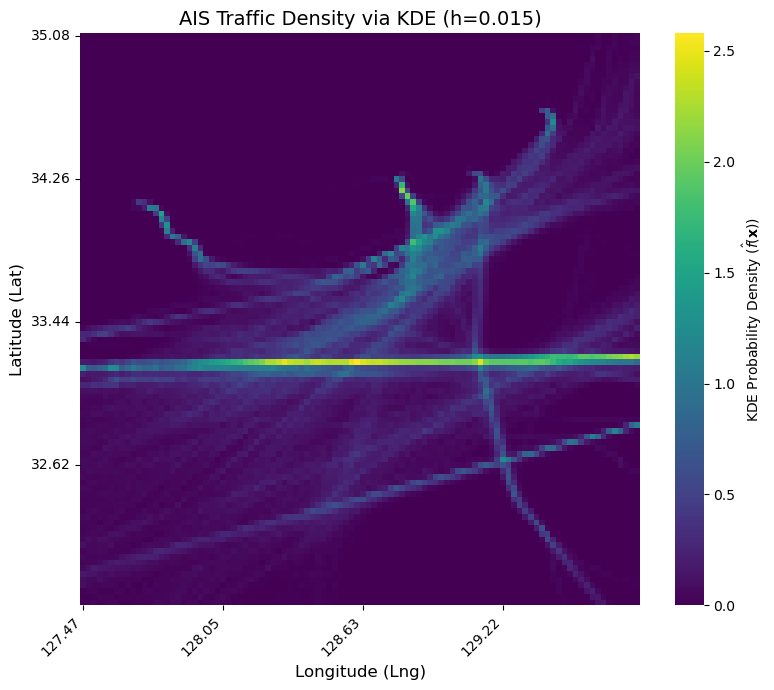


KDE Matrix Shape: (100, 100)
Bandwidth (h): 0.015


In [25]:

# 2. Plotting the Heatmap (using seaborn)
plt.figure(figsize=(8, 7))

# The KDE matrix's row index 0 corresponds to the highest latitude (lat_max),
# because np.meshgrid creates the grid from top to bottom.
# To ensure lat_min is at the bottom of the plot, we must reverse the matrix vertically.
kde_matrix_flipped = np.flipud(kde_matrix)

# Use seaborn to draw the heatmap
ax = sns.heatmap(
    kde_matrix_flipped, 
    cmap="viridis",  # Use a standard continuous color map for KDE
    cbar_kws={'label': f'KDE Probability Density ($\hat{{f}}(\\mathbf{{x}})$)'}
)

# Set title and axis labels
ax.set_title(f'AIS Traffic Density via KDE (h={bandwidth_h})', fontsize=14)
ax.set_xlabel('Longitude (Lng)', fontsize=12)
ax.set_ylabel('Latitude (Lat)', fontsize=12)

# 3. Customizing Axis Tick Labels to show real geographic coordinates

# We display only a few major ticks, e.g., 5 ticks
num_ticks = 5
# Calculate the step size for placing ticks
tick_step = grid_size // (num_ticks - 1)

# X-axis labels (Longitude)
# Ticks should be placed at the center of the grid cells for visualization
x_tick_positions = np.arange(0, grid_size, tick_step) + 0.5 # Add 0.5 to center ticks in cells
x_tick_labels = [f'{lng_centers[i]:.2f}' for i in range(0, grid_size, tick_step)]

# Y-axis labels (Latitude)
# Since we flipped the matrix (kde_matrix_flipped), the row index 0 now corresponds to lat_min (lowest latitude).
# So we use the centers in their natural ascending order for the labels, but reversed for visualization.
y_tick_positions = np.arange(0, grid_size, tick_step) + 0.5
y_tick_labels = [f'{lat_centers[i]:.2f}' for i in range(0, grid_size, tick_step)]
y_tick_labels_reversed = y_tick_labels[::-1] # Reverse labels for top-down matrix visualization

ax.set_xticks(x_tick_positions)
ax.set_xticklabels(x_tick_labels, rotation=45, ha='right')

ax.set_yticks(y_tick_positions)
ax.set_yticklabels(y_tick_labels_reversed) 

# Adjust layout to prevent labels from overlapping
plt.tight_layout()
plt.savefig('point_density_KDE.png',  dpi = 1200)
plt.show()

print("\nKDE Matrix Shape:", kde_matrix.shape)
print("Bandwidth (h):", bandwidth_h)